Nuestra semilla es la de la alumna Lidia Valera López, con NIA 100522236, por lo que nuestro bank es el 9 (3+6)

Lo primero que hacemos es cargar los datos

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Cargamos los datos
df = pd.read_pickle("bank_09.pkl") 

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Ver número de instancias y variables

In [10]:
n_instancias, n_variables = df.shape

print(f"Número de instancias: {n_instancias}")
print(f"Número de variables: {n_variables}")

Número de instancias: 11000
Número de variables: 17


Ver tipo de variables (si son numéricas, categóricas u ordinales)

In [11]:
tipos = df.dtypes
print(tipos)

num_vars = df.select_dtypes(include=[np.number]).columns
cat_vars = df.select_dtypes(include=['object']).columns
ordinal_vars = ["education"]

cat_vars = [var for var in cat_vars if var not in ordinal_vars]
# Quitar variables ordinales de las variables categóricas

print(f"Variables numéricas: {num_vars}")
print(f"Variables categóricas: {cat_vars}")
print(f"Variables ordinales: {ordinal_vars}")


age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object
Variables numéricas: Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')
Variables categóricas: ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']
Variables ordinales: ['education']


Comprobar categóricas con alta cardinalidad (mas de 10 valores únicos)

In [12]:
for var in cat_vars:
    if df[var].nunique() > 10:
        print(f"{var} con alta cardinalidad: {df[var].nunique()} valores únicos")



job con alta cardinalidad: 12 valores únicos
month con alta cardinalidad: 12 valores únicos


Ver variables con valores faltantes

In [13]:
for var in df.columns:
    if df[var].isnull().any():
        print(f"{var} con valores nulos")
    if df[var].any()=="None":
        print(f"{var} con valores nulos")    
        break

job con valores nulos
marital con valores nulos


Ver columnas constantes

In [14]:
print("Frecuencias de los valores únicos:")
for var in df.columns:
    value = df[var].value_counts().max() / len(df)
    print(f"{var}: {value:.2f}")
    if value > 0.85:
        print(f"{var} es una variable muy constante")
    if value == 1.0:
        print(f"{var} es una variable constante")
constantes = [col for col in df.columns if df[col].nunique() == 1]
print("Columnas constantes:", constantes)
# No se han encontrado variables constantes.

Frecuencias de los valores únicos:
age: 0.04
job: 0.23
marital: 0.56
education: 0.49
default: 0.98
default es una variable muy constante
balance: 0.07
housing: 0.53
loan: 0.87
loan es una variable muy constante
contact: 0.72
day: 0.05
month: 0.25
duration: 0.00
campaign: 0.43
pdays: 0.75
previous: 0.75
poutcome: 0.75
deposit: 0.53
Columnas constantes: []


Ver columnas tipo ID

In [15]:
posibles_id = [col for col in df.columns if df[col].nunique() == len(df)]
print("Columnas tipo ID:", posibles_id)

if posibles_id == []:
    print("No se han encontrado variables que podrían ser IDs (todos los valores son únicos).")


Columnas tipo ID: []
No se han encontrado variables que podrían ser IDs (todos los valores son únicos).


Ver si es un problema de clasificación o regresión

In [16]:

target = "deposit"
print(df[target].dtype)
print(df[target].nunique(), "valores únicos")
df["deposit"].value_counts()


#El target presenta dos valores únicos lo que supone un problema de clasificación binaria.
#La metrica de evaluación más adecuada para este tipo de problema sería la precisión, 
# la recall o el F1-score, dependiendo de la importancia que se le dé a los falsos positivos y falsos negativos.

object
2 valores únicos


deposit
no     5780
yes    5220
Name: count, dtype: int64

La variable objetivo deposit presenta una distribución relativamente equilibrada entre clases (aproximadamente 53% frente a 47%). Debido a este balance, la métrica accuracy resulta adecuada para evaluar el rendimiento del modelo, ya que no existe un desbalance significativo que pueda sesgar esta medida.
Como métrica principal se utilizará accuracy. Adicionalmente, se podrá analizar ROC-AUC para evaluar la capacidad discriminativa del modelo.

Ver si está balanceado

deposit
no     0.525455
yes    0.474545
Name: proportion, dtype: float64


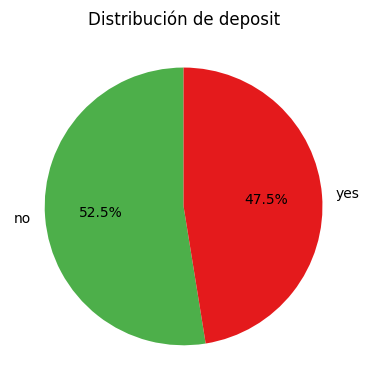

In [17]:
props = df[target].value_counts(normalize=True)

print(props)


if props.iloc[0] > 0.70:
    print(f"El target '{target}' está desbalanceado: {props[0]:.2f} de la clase mayoritaria.")

# Gráfico pie para visualizar la distribución del target
plt.figure(figsize=(4, 4))
props.plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4daf4a", "#e41a1c"],
    legend=False,
    ylabel=""
)
plt.title("Distribución de deposit")
plt.tight_layout()
plt.show()

Analizar pdays

Estadísticas de pdays (todos los datos):
count    11000.000000
mean        52.054364
std        108.424506
min          0.000000
25%          0.000000
50%          0.000000
75%         20.250000
max        854.000000
Name: pdays, dtype: float64

Los 10 valores más frecuentes de pdays:
pdays
0      8203
92      105
182      88
91       82
181      79
183      73
184      51
94       42
93       40
95       37
Name: count, dtype: int64
Número de clientes no contactados (pdays = 0): 8203
Número de clientes contactados (pdays != 0): 2797

Proporción de no contactados: 0.7457272727272727
Proporción de contactados: 0.25427272727272726


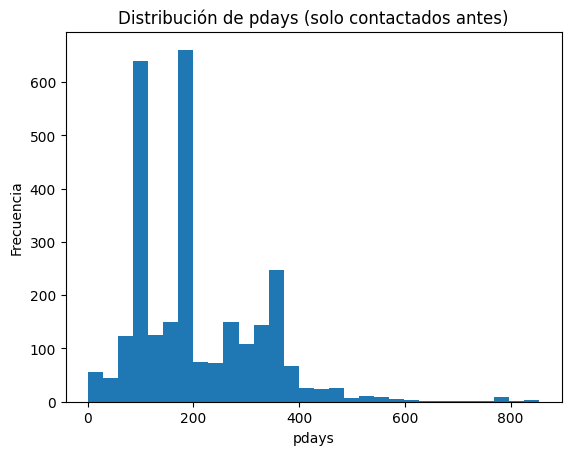

In [18]:
target = "pdays"

# Estadísticas generales
df["pdays"] = df["pdays"].replace(-1, 0)
print(f"Estadísticas de {target} (todos los datos):")
print(df[target].describe())
print()
print(f"Los 10 valores más frecuentes de {target}:")
print(df[target].value_counts().head(10))

# Número de clientes no contactados (pdays = 0) vs contactados (pdays != 0)
n_not_contacted = (df[target] == 0).sum()
n_contacted = (df[target] != 0).sum()

print("Número de clientes no contactados (pdays = 0):", n_not_contacted)
print("Número de clientes contactados (pdays != 0):", n_contacted)

# Opcional: comparación de proporciones
print()
print("Proporción de no contactados:", n_not_contacted / len(df))
print("Proporción de contactados:", n_contacted / len(df))

# Histograma de pdays para los contactados (pdays != 0)
import matplotlib.pyplot as plt

pdays_contacted = df.loc[df[target] != 0, target]
plt.hist(pdays_contacted, bins=30)
plt.title("Distribución de pdays (solo contactados antes)")
plt.xlabel("pdays")
plt.ylabel("Frecuencia")
plt.show() 


Decidir como se va a realizar la evaluación

Al tratarse de un problema de clasificación binaria ("deposit" toma valores Yes/No), tenemos que analizar el desbalanceo para determinar la métrica. 
Al estar muy balanceado determinamos que la accuracy (precisión) es una métrica perfectamente válida para reflejar el rendimiento del modelo. 

Adicionalmente, para evaluar la capacidad discriminativa del modelo, se podrá analizar ROC_AUC.

División holdout (train/test)

In [19]:
from sklearn.model_selection import train_test_split

# Separar variables predictoras y variable objetivo
x = df.drop(columns=["deposit"]) # Variables predictoras (features)
y = df["deposit"] # Variable objetivo (target)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/3,
                                                    stratify=y,
                                                      random_state=42)

print("Tamaño del conjunto de entrenamiento:", x_train.shape[0])
print("Tamaño del conjunto de prueba:", x_test.shape[0])


Tamaño del conjunto de entrenamiento: 7333
Tamaño del conjunto de prueba: 3667


Inner evaluation (crossvalidation)

Para la evaluación interna se empleará validación cruzada estratificada en 5 folds, que permitirá comparar diferentes modelos y realizar la optimización de hiprtparámetros empleando sólamente el conjunto de entrenamiento.

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
#Diccionario para almacenar los resultados de las validaciones cruzadas
inner_scores = {}

Método de escalado con KNN, evaluación de alternativas

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier  # Cambiado a Classifier
from sklearn import metrics
target = "deposit"

# 1. Definir los escaladores a probar
scalers = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler()
}

# This variable will contain the 5 cross validation accuracies, one per iteration
scores = {'Standard': 0, 'MinMax': 0, 'Robust': 0}

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_vars),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_vars),
        ('ord', OrdinalEncoder(), ordinal_vars)
    ]
)
print("Iteraciones de validación cruzada:")

for train_index, test_index in cv.split(x, y):
    # Getting the actual training and testing partitions out of the indices
    X_train, X_test = x.iloc[train_index,:], x.iloc[test_index,:]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    mean = 0

    for element in scalers:
        print(f"Evaluando escalar: {element}")
    # Training the model for this particular cross validation iteration
        pipe = Pipeline([
            ('prepro', preprocessor),
            ('scaler', scalers[element]),
            ('knn', KNeighborsClassifier())]
        )
        pipe.fit(X_train, y_train)
        y_test_pred = pipe.predict(X_test)
        accuracy_knn = metrics.accuracy_score(y_test, y_test_pred)

        # We add this accuracy to the list
        scores[element] += accuracy_knn
for element in scalers:
    scores[element] = scores[element]/3

# Transforming scores from list to numpy array (this is just a technicality)
scores_values = np.array(list(scores.values()))
scores_names = list(scores.keys())
for name, score in zip(scores_names, scores_values):
    print(f"Accuracy para escalar {name} : {score:.4f}")
    
print(f"Mejor escalar: {scores_names[np.argmax(scores_values)]}")


Iteraciones de validación cruzada:
Evaluando escalar: Standard
Evaluando escalar: MinMax
Evaluando escalar: Robust
Evaluando escalar: Standard
Evaluando escalar: MinMax
Evaluando escalar: Robust
Evaluando escalar: Standard
Evaluando escalar: MinMax
Evaluando escalar: Robust
Accuracy para escalar Standard : 0.7645
Accuracy para escalar MinMax : 0.7293
Accuracy para escalar Robust : 0.7983
Mejor escalar: Robust


Como medimos con accuracy, el mejor método es aquel cuya accuracy sea la mayor, por tanto lo mejor es Robust.

KNN y Árboles

Evaluación de hiperparámetros por omisión

In [65]:
import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score



modelos = {
    'KNN (Mejor Scaler)': Pipeline([
        ('prepro', preprocessor),
        ('scaler', RobustScaler()), # El ganador de tu prueba anterior
        ('knn', KNeighborsClassifier()) # Parámetros por defecto (k=5)
    ]),
    'Árbol de Decisión': Pipeline([
        ('prepro', preprocessor),
        ('dt', DecisionTreeClassifier(random_state=42)) # Parámetros por defecto
    ])
}

for nombre, pipe in modelos.items():
    inicio = time.time() # Empezamos el cronómetro
    
    # Hacemos la validación cruzada para obtener la nota media
    scores = cross_val_score(pipe, X_train, y_train, cv=cv) 
    
    fin = time.time() # Paramos el cronómetro
    
    print(f"{nombre} - Accuracy: {scores.mean():.4f} - Tiempo: {fin - inicio:.4f}s")

KNN (Mejor Scaler) - Accuracy: 0.7847 - Tiempo: 0.7621s
Árbol de Decisión - Accuracy: 0.7754 - Tiempo: 0.7780s


El mejor modelo es el que tiene la mayor accuracy media. En este caso sería el modelo de KNN con el escalador RobustScaler, ya que obtuvo una mayor precisión en la validación cruzada en comparación con el Árbol de Decisión.

Interpretacion de como concebir decisiones a través de árboles poco profundos